# TP DSP - Grupo 5: Filtrado e Identificación de Sistemas

## Introducción

Un analizador de doble canal analiza simultáneamente la entrada y salida de un sistema 
para caracterizarlo en frecuencia. La respuesta en frecuencia H(ω) se obtiene como:

$$H(\omega) = \frac{Y(\omega)}{X(\omega)}$$

donde Y(ω) y X(ω) son las transformadas de Fourier de la salida y entrada respectivamente.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from funciones import *
import timeit


%matplotlib inline

## Parte 1: Herramientas de análisis

### 1. Generación y gráfico de señales

A continuación se presentan las herramientas destinadas a la generación de señales y su representación visual, mediante ejemplos.

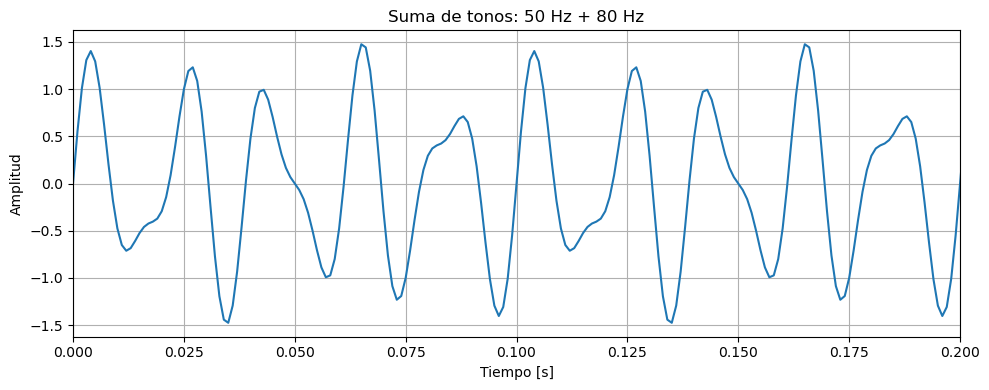

In [40]:
# Parámetros
fs = 1000       # frecuencia de muestreo: 1000 Hz
duracion = 1    # 1 segundo

# Generamos una suma de tonos puros: 50 Hz y 200 Hz
senal = generar_suma_tonos(
    frecuencias=[50, 80],
    amplitudes=[1, 0.5],
    fs=fs,
    duracion=duracion
)

# Graficamos la señal temporal
graficar_senales(senal, fs=fs, titulo="Suma de tonos: 50 Hz + 80 Hz", xlim=(0, 0.2))

A continuación se grafica el espectro de dicha señal mediante una función que utiliza la herramienta de la DFT optimizada mediante el algoritmo de la FFT. Se descarta la mitad del espectro graficado, pues aquí es donde se ubica el aliasing visual producto de las bases de la transformada.

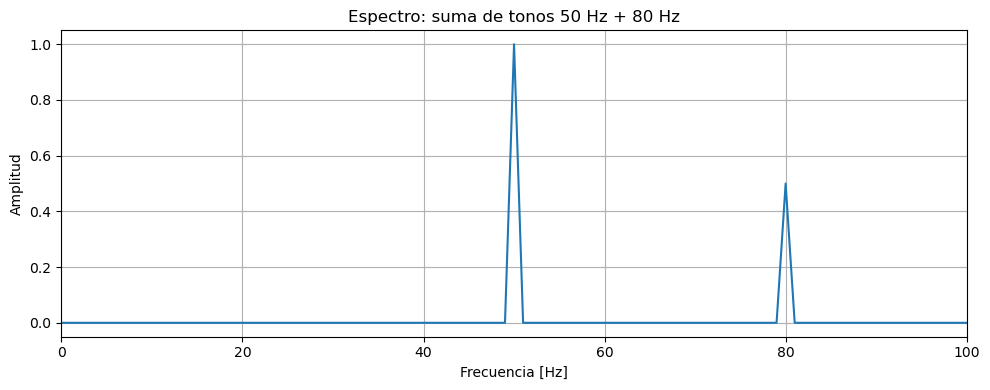

In [41]:
# Graficamos el espectro de la misma señal
graficar_espectros(senal, fs=fs, titulo="Espectro: suma de tonos 50 Hz + 80 Hz", xlim=(0, 100))

Los dos picos en el espectro corresponden exactamente a las frecuencias de los tonos 
generados (50 Hz y 80 Hz), con amplitudes proporcionales a las indicadas (1 y 0.5 
respectivamente).

### 2. Señales con ruido blanco
#### Suma de tonos puros

Aquí se añade ruido a la señal generada:

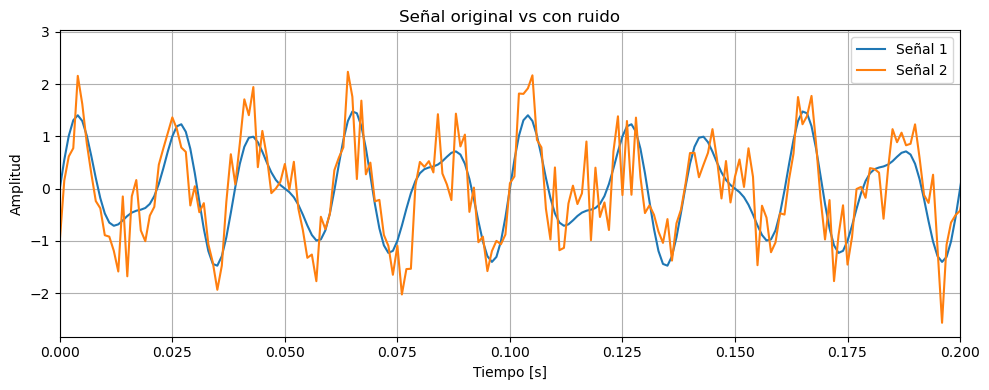

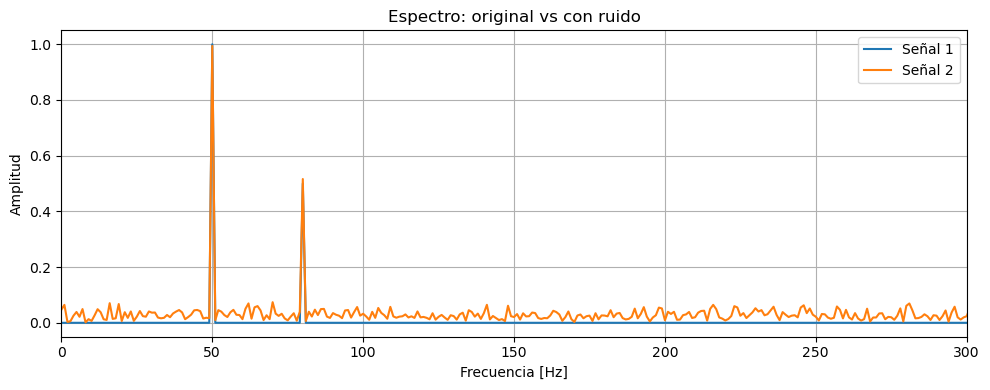

In [42]:
tonos_con_ruido, ruido = agregar_ruido_blanco(senal, amplitud=0.5)

graficar_senales([senal, tonos_con_ruido], fs=fs, titulo="Señal original vs con ruido", xlim=(0, 0.2))

graficar_espectros([senal, tonos_con_ruido], fs=fs, titulo="Espectro: original vs con ruido", xlim=(0, 300))

### Observación

Al agregar ruido blanco, en el dominio temporal la señal se ve "sucia" pero todavía 
se reconoce la forma original. En el espectro, el efecto es más revelador: el ruido 
blanco distribuye energía en **todas las frecuencias** de manera uniforme, lo que se 
manifiesta como un "piso" de perturbaciones a lo largo de todo el espectro, en lugar 
de los dos picos limpios de la señal original.

Esto ilustra una propiedad fundamental del ruido blanco: su densidad espectral de 
potencia es constante en todas las frecuencias.

#### Señal musical

Se genero una melodia a la cual se le fue agregando distintas amplitudes de ruido blanco

In [43]:
fs= 44100
notas = [523.25, 659.25, 783.99, 523.25] # Do, Mi, Sol
duraciones = [0.5,0.5,0.5,1]

melodia = generar_melodia(notas, duraciones, fs)

amplitudes_ruido = [0.01, 0.05, 0.20]  # Tres niveles de ruido

for amp in amplitudes_ruido:

    senal_con_ruido, ruido = agregar_ruido_blanco(melodia, amp)

    generate_wav(senal_con_ruido,f"melodia_ruido_{amp}.wav",fs )
    generate_wav(ruido,f"solo_ruido_{amp}.wav",fs)

### 3. Filtros y respuesta al impulso

Se analizan los tres filtros requeridos: media móvil, peine y FIR.

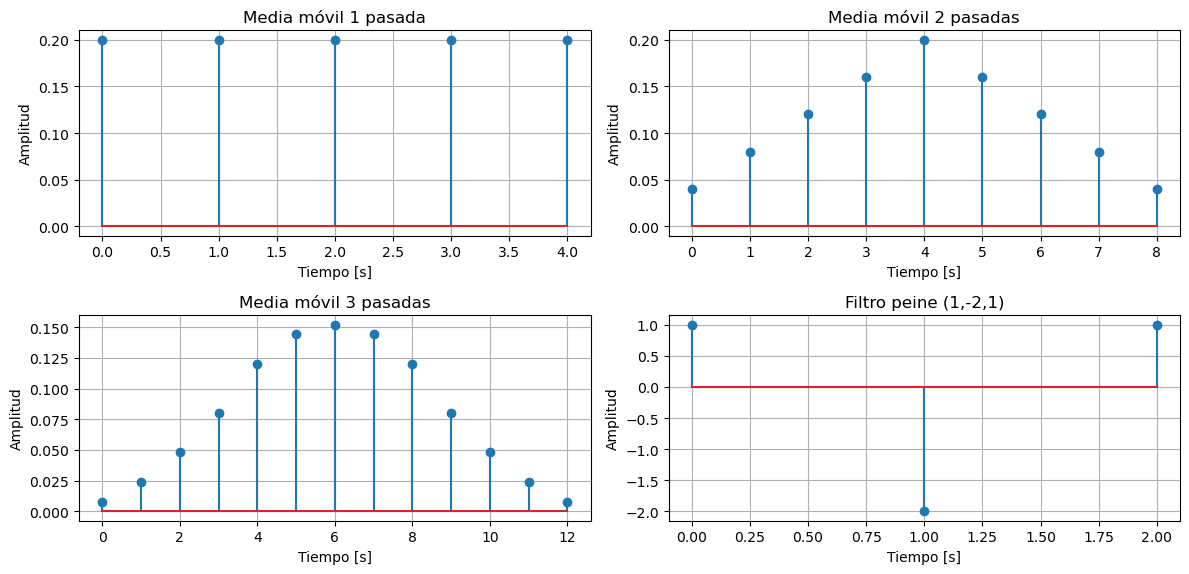

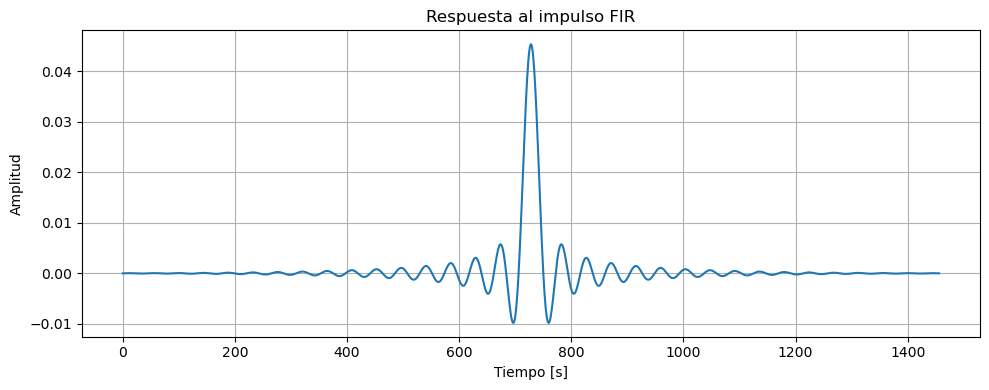

In [44]:
# se generan las respuestas al impulso de cada filtro

h_1p = filtro_media_movil(M=5)
h_2p = np.convolve(h_1p, h_1p)
h_3p = np.convolve(h_2p, h_1p)

h_peine = filtro_peine(b0=1, b1=-2, b2=1)  # un ejemplo de filtro peine

h_fir = cargar_filtro_fir("fir_hamming_1000Hz.npy")

graficar_senales(
    [
        h_1p,
        h_2p,
        h_3p,
        h_peine,
    ],
    subplots=True,
    stem=True,
    ncols=2,
    titles=[
        "Media móvil 1 pasada",
        "Media móvil 2 pasadas",
        "Media móvil 3 pasadas",
        "Filtro peine (1,-2,1)"
    ]
)


graficar_senales(
    h_fir,
    titulo="Respuesta al impulso FIR",
    stem=False
)

### 4. Caracterización en frecuencia de los filtros (módulo y fase)

Para analizar el comportamiento de cada filtro en frecuencia con las funciones armadas, se calcula su respuesta 
en frecuencia H(ω) aplicando el filtro a un impulso y luego calculando la FFT, con la frecuencia normalizada la frecuencia dividida por la frecuencia de muestreo, logrando que de esta manera se pueda caracterizar el filtro sin depender de una `fs`.

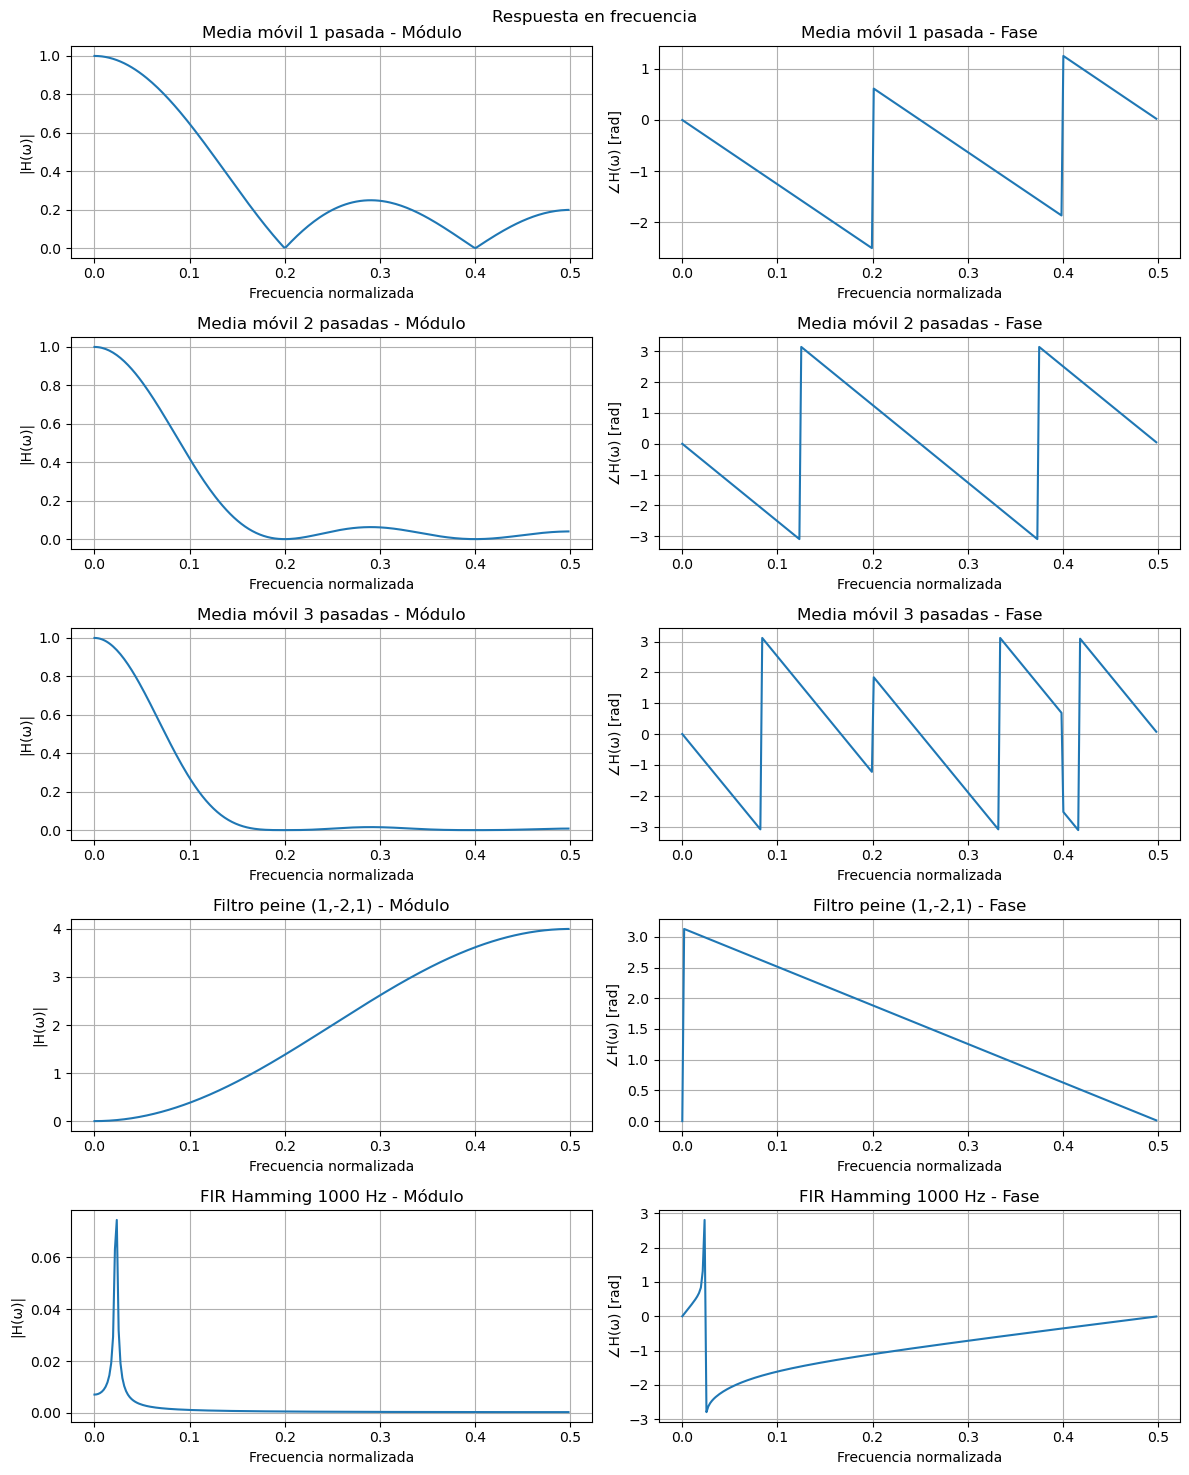

In [45]:
# Creamos impulso
N = 512
impulso = np.zeros(N)
impulso[0] = 1

# Salidas
y_1p = filtrar_convolucion(impulso, h_1p)[:N]
y_2p = filtrar_convolucion(impulso, h_2p)[:N]
y_3p = filtrar_convolucion(impulso, h_3p)[:N]
y_peine = filtrar_convolucion(impulso, h_peine)[:N]
y_fir = filtrar_convolucion(impulso, h_fir)[:N]

# H(w)
H_1p, freqs = calcular_H(impulso, y_1p)
H_2p, _ = calcular_H(impulso, y_2p)
H_3p, _ = calcular_H(impulso, y_3p)
H_peine, _ = calcular_H(impulso, y_peine)
H_fir, _ = calcular_H(impulso, y_fir)

# Graficar módulo y fase
graficar_H(
    [
        H_1p,
        H_2p,
        H_3p,
        H_peine,
        H_fir
    ],
    [
        freqs,
        freqs,
        freqs,
        freqs,
        freqs
    ],
    subplots=True,
    titles=[
        "Media móvil 1 pasada",
        "Media móvil 2 pasadas",
        "Media móvil 3 pasadas",
        "Filtro peine (1,-2,1)",
        "FIR Hamming 1000 Hz"
    ]
)

### Observación: caracterización en frecuencia de los filtros

#### Media móvil — efecto de las pasadas

La respuesta al impulso de una sola pasada es un pulso rectangular de ancho M. Al aumentar el número de pasadas, la convolución sucesiva de ese pulso consigo mismo produce formas cada vez más suaves: triangular con 2 pasadas, y acampanada (aproximación a una Gaussiana) con 3. Esto se refleja directamente en la respuesta en frecuencia:

- **Módulo**: con más pasadas, el lóbulo principal se mantiene centrado en DC pero los lóbulos secundarios de la sinc se atenúan progresivamente. La respuesta se aproxima a la de un filtro Gaussiano ideal, que no tiene lóbulos laterales. El filtro sigue siendo **pasa-bajos** en todos los casos.
- **Fase**: los tres filtros presentan fase lineal, propiedad característica de todos los filtros FIR simétricos. Esto implica retardo de grupo constante: todas las frecuencias se retrasan la misma cantidad de tiempo, preservando la forma de la señal filtrada.

#### Filtro peine [1, −2, 1]

El comportamiento del filtro peine es opuesto al de la media móvil:

- **Módulo**: la ganancia es cero en DC (frecuencia normalizada = 0) y máxima en la frecuencia de Nyquist (0.5). Esto se verifica directamente: la suma de coeficientes es 1 − 2 + 1 = 0, lo que garantiza atenuación total de la componente continua. Se trata de un filtro **pasa-altos** que resalta los cambios rápidos entre muestras consecutivas.
- **Fase**: también lineal, al ser un FIR simétrico.

#### Filtro de respuesta al impulso finita

A diferencia de la media móvil y el filtro peine (que son filtros de coeficientes simples y fijos), el diseño de filtros FIR mediante el método de ventaneo permite alcanzar una alta selectividad:

- **Módulo:** El filtro diseñado mediante ventana de Hamming presenta un comportamiento pasa-bajos, conservando las componentes ubicadas dentro de la banda pasante y atenuando progresivamente las frecuencias superiores a la frecuencia de corte. El ventaneo de la respuesta ideal reduce significativamente los lóbulos secundarios en la banda de rechazo respecto de un truncado rectangular, aunque introduce un leve ensanchamiento de la banda de transición.
- **Fase:** Debido a la simetría de sus coeficientes temporales ($h[n] = h[M-n]$), el filtro presenta fase lineal dentro de la región donde el módulo posee amplitud significativa. Esto implica retardo de grupo aproximadamente constante y preservación de la forma temporal de las componentes que atraviesan el filtro. En regiones donde la ganancia del filtro tiende a cero, la representación de fase pierde significado práctico y puede presentar discontinuidades numéricas.

#### Comparación entre filtros

| Filtro | Tipo | Ganancia en DC | Lóbulos laterales |
|---|---|---|---|
| Media móvil 1 pasada | Pasa-bajos | 1 | Presentes (sinc) |
| Media móvil 2 pasadas | Pasa-bajos | 1 | Reducidos |
| Media móvil 3 pasadas | Pasa-bajos | 1 | Muy reducidos (Gaussiana) |
| Peine [1,−2,1] | Pasa-altos | 0 | N/A |
| FIR | Pasa-bajos | 0 | Ultra reducidos|

### 5. Filtrado de la señal con ruido (MEDIA MOVIL)

Se procede al filtrado de media móvil de los tonos con ruido por medio de la convolucion circular, y tambien por medio de la trasformada, para evaluar las diferencias entre ambos métodos.

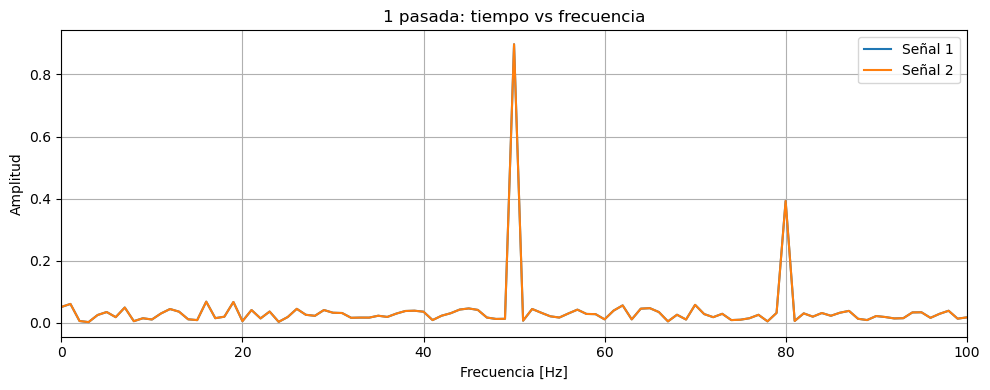

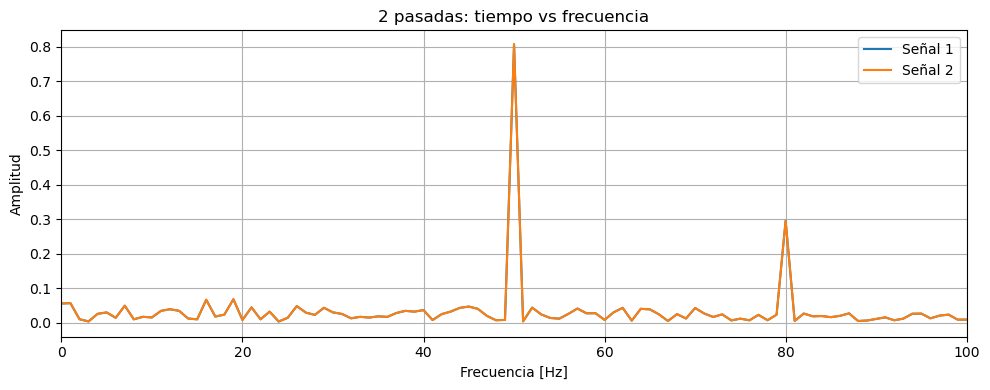

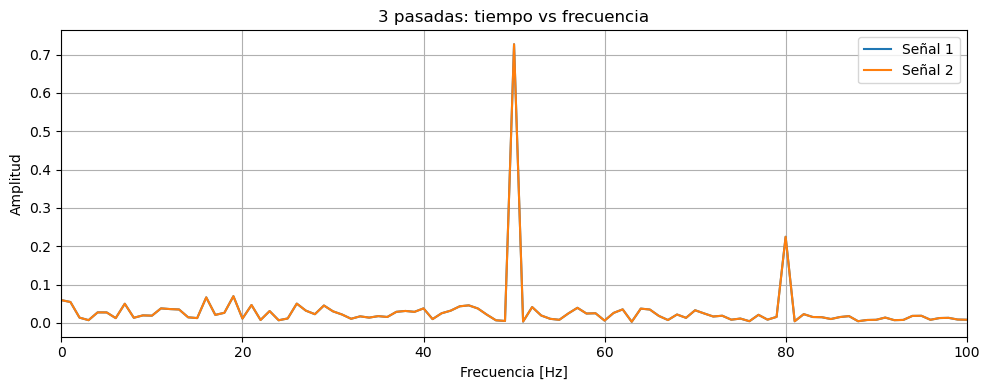

In [46]:
fs=1000
# Se calculan los filtrados
y_1p_tiempo = filtrar_convolucion(tonos_con_ruido, h_1p)[:len(tonos_con_ruido)]
y_2p_tiempo = filtrar_convolucion(tonos_con_ruido, h_2p)[:len(tonos_con_ruido)]
y_3p_tiempo = filtrar_convolucion(tonos_con_ruido, h_3p)[:len(tonos_con_ruido)]

y_1p_freq   = filtrar_frecuencia(tonos_con_ruido, h_1p)[:len(tonos_con_ruido)]
y_2p_freq   = filtrar_frecuencia(tonos_con_ruido, h_2p)[:len(tonos_con_ruido)]
y_3p_freq   = filtrar_frecuencia(tonos_con_ruido, h_3p)[:len(tonos_con_ruido)]

graficar_espectros([y_1p_tiempo, y_1p_freq], fs=fs, titulo="1 pasada: tiempo vs frecuencia", xlim=(0, 100))
graficar_espectros([y_2p_tiempo, y_2p_freq], fs=fs, titulo="2 pasadas: tiempo vs frecuencia", xlim=(0, 100))
graficar_espectros([y_3p_tiempo, y_3p_freq], fs=fs, titulo="3 pasadas: tiempo vs frecuencia", xlim=(0, 100))



Los tres métodos dan exactamente lo mismo, entonces la diferencia no está en el resultado.

In [47]:
# Comparación de tiempos de cómputo (usamos h_3p, el filtro más largo)
N = 1000
t_conv = timeit.timeit(lambda: filtrar_convolucion(tonos_con_ruido, h_3p), number=N) / N * 1000
t_freq = timeit.timeit(lambda: filtrar_frecuencia(tonos_con_ruido, h_3p), number=N) / N * 1000

print(f"Convolución temporal:      {t_conv:.3f} ms")
print(f"Convolución en frecuencia: {t_freq:.3f} ms")
print(f"Razón: {t_conv/t_freq:.1f}x")

Convolución temporal:      0.023 ms
Convolución en frecuencia: 0.063 ms
Razón: 0.4x


### Observación: convolución temporal vs convolución circular en frecuencia

#### Tiempos de cómputo

La convolución en frecuencia resulta más rápida que la convolución temporal, especialmente a medida que el filtro se hace más largo. Esto se debe a que la multiplicación espectral opera sobre vectores de longitud fija (determinada por el zero-padding), mientras que la convolución directa tiene complejidad O(N·M), donde M es la longitud del filtro. Con más pasadas, M crece, y la ventaja del método en frecuencia se vuelve más pronunciada.

Ambos métodos producen resultados equivalentes: el zero-padding aplicado en `filtrar_frecuencia` evita el aliasing circular, haciendo que la convolución circular sea idéntica a la lineal.


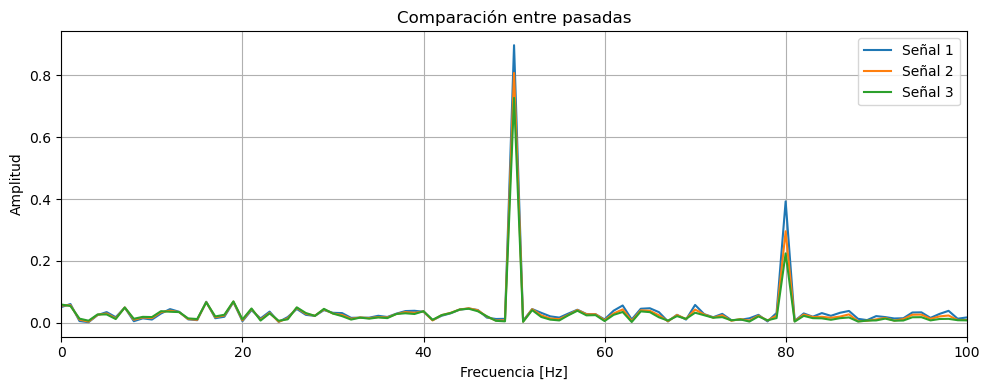

In [48]:
# Comparación entre pasadas: efecto en el espectro
graficar_espectros(
    [y_1p_tiempo, y_2p_tiempo, y_3p_tiempo],
    fs=fs, titulo="Comparación entre pasadas", xlim=(0, 100)
)

#### Efecto de las pasadas sobre el espectro

Al comparar los espectros de las señales filtradas con 1, 2 y 3 pasadas se observa que:
- Con más pasadas, la atenuación de las frecuencias altas es progresivamente mayor.
- Los picos de los tonos (50 Hz y 200 Hz) se preservan en todos los casos, ya que se encuentran dentro de la banda de paso del filtro.
- El piso de ruido se reduce con cada pasada adicional, lo que confirma el mayor efecto suavizante de los filtros con múltiples pasadas.

### Observación: convolución temporal vs circular en frecuencia

**Efecto del filtrado:** el filtro media móvil con M=10 suaviza más la señal que M=3, 
eliminando más ruido pero también "borrando" algo de detalle de la señal original. 
Existe un compromiso entre eliminación de ruido y preservación de la señal.

**Equivalencia de métodos:** las curvas de convolución temporal y convolución circular 
en frecuencia se superponen perfectamente. Esto verifica el **teorema de convolución**: 
convolucionar en el tiempo es equivalente a multiplicar en frecuencia. El zero-padding 
aplicado en `filtrar_frecuencia()` es clave para que la convolución circular sea 
equivalente a la lineal.

### Filtrado de la señal con ruido (PEINE)

Dado que se verificó experimentalmente que el filtrado mediante convolución directa en el dominio temporal y mediante multiplicación espectral en frecuencia producen resultados equivalentes (presentando únicamente diferencias del orden del error numérico computacional), a partir de este punto se utilizará el método basado en FFT para realizar el filtrado.

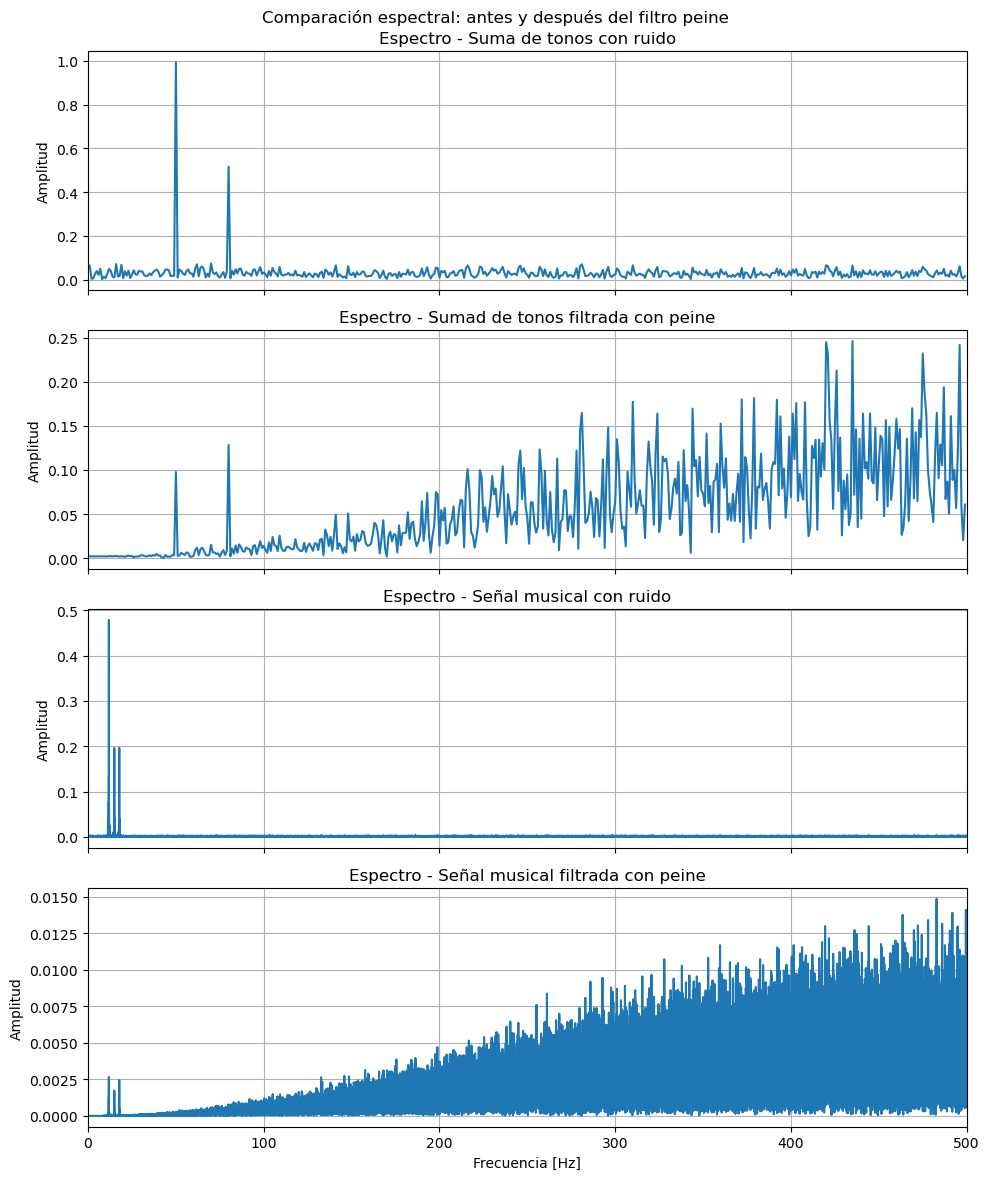

In [49]:
y_peine_freq = filtrar_frecuencia(tonos_con_ruido, h_peine)[:len(tonos_con_ruido)]
y_peine_freq2 = filtrar_frecuencia(senal_con_ruido, h_peine)[:len(senal_con_ruido)]


graficar_espectros(
    [ 
        tonos_con_ruido,
        y_peine_freq,
        senal_con_ruido,
        y_peine_freq2
    ],
    fs=fs,
    titulo="Comparación espectral: antes y después del filtro peine",
    subplots=True,
    xlim=(0, 500),
    titles=[
        "Espectro - Suma de tonos con ruido",
        "Espectro - Sumad de tonos filtrada con peine",
        "Espectro - Señal musical con ruido",
        "Espectro - Señal musical filtrada con peine"
    ]
)

### Observación:

**Efecto del filtrado:** el filtro peine h=[1,−2,1] modifica la señal de manera muy distinta al filtro media móvil. En lugar de suavizarla, resalta las variaciones rápidas y los cambios bruscos entre muestras consecutivas. Como consecuencia, la salida presenta oscilaciones más pronunciadas y una reducción importante de las componentes de baja frecuencia. En el espectro se aprecia que las frecuencias bajas son fuertemente atenuadas, mientras que las componentes más altas permanecen más visibles, evidenciando el carácter pasa-altos del filtro.


### Filtrado de la señal con ruido (FIR)

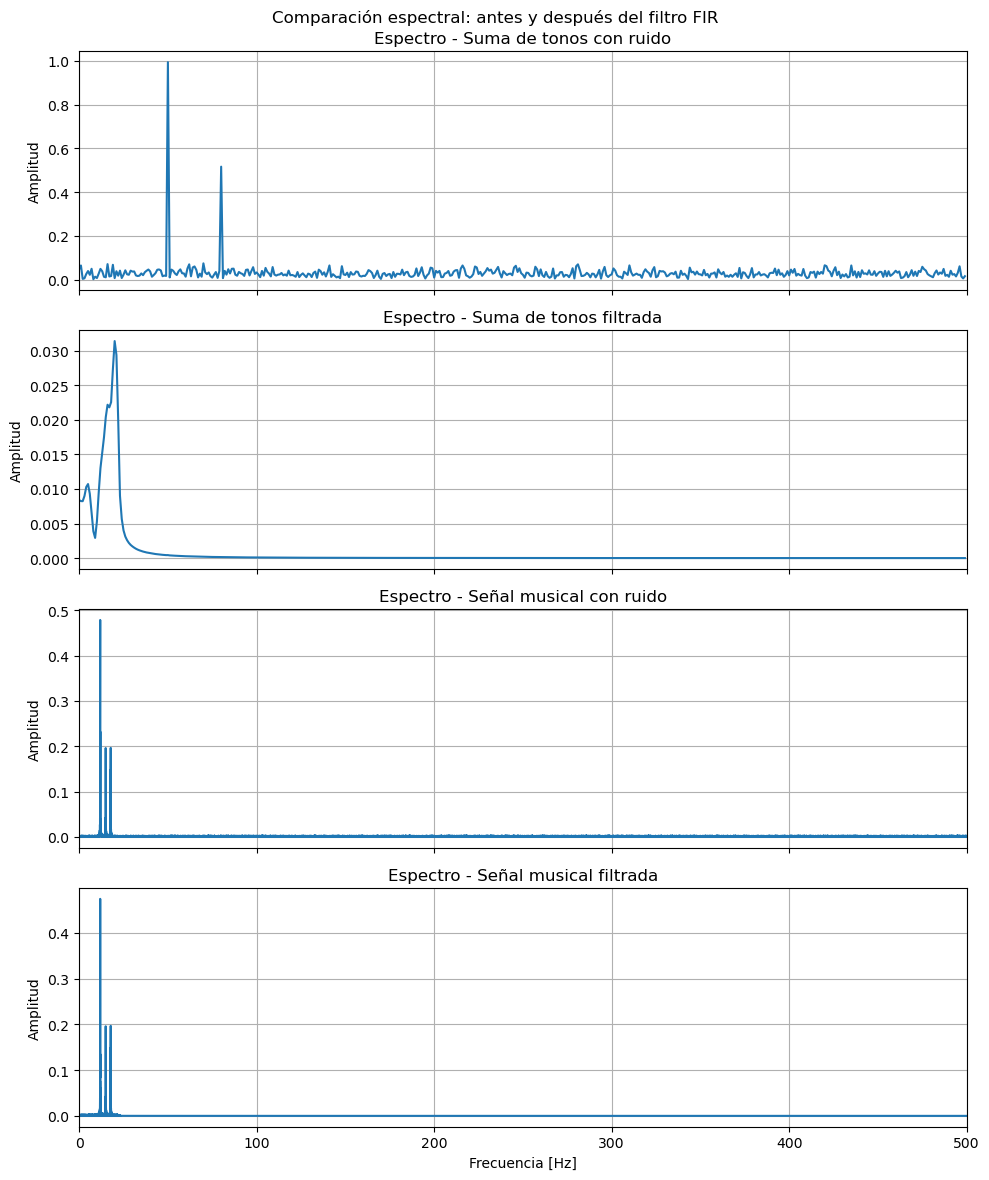

In [55]:
# Aplicamos el filtro FIR a la señal con ruido
# Comparación entre convolución temporal y filtrado en frecuencia

fir = cargar_filtro_fir("fir_hamming_1000Hz.npy")

# Filtrado
y_fir_freq = filtrar_frecuencia(
    tonos_con_ruido,
    fir
)[:len(tonos_con_ruido)]

y_fir_freq2 = filtrar_frecuencia(
    senal_con_ruido,
    fir
)[:len(senal_con_ruido)]

# Calculamos retardo aproximado del FIR
delay = (len(fir) - 1) // 2

# Recortamos para visualizar después del transitorio
inicio = delay
fin = delay + 200

# Graficamos
graficar_espectros(
    [ 
        tonos_con_ruido,
        y_fir_freq,
        senal_con_ruido,
        y_fir_freq2
    ],
    fs=fs,
    titulo="Comparación espectral: antes y después del filtro FIR",
    subplots=True,
    xlim=(0, 500),
    titles=[
        "Espectro - Suma de tonos con ruido",
        "Espectro - Suma de tonos filtrada",
        "Espectro - Señal musical con ruido",
        "Espectro - Señal musical filtrada"
    ]
)


### Observacion

El filtro FIR utilizado posee 1457 coeficientes, por lo que introduce un retardo aproximado de 728 muestras, correspondiente al retardo de grupo de un FIR lineal y simétrico. Para evitar interpretar el transitorio inicial como una atenuación excesiva del contenido de la señal, la comparación temporal se realizó desplazando la visualización hacia una región posterior al retardo.
En el análisis espectral se observó que el filtro conserva las componentes principales de baja frecuencia presentes en las señales de entrada y atenúa componentes distribuidas sobre una banda más amplia, comportamiento consistente con un filtro FIR pasa-bajos diseñado mediante ventana de Hamming. La reducción del contenido fuera de banda resulta más evidente en señales contaminadas con ruido, donde el filtrado mejora la relación entre componentes útiles y no deseadas sin modificar significativamente la estructura espectral dominante.

### 6. IDENTIFICACIÓN DE SISTEMA

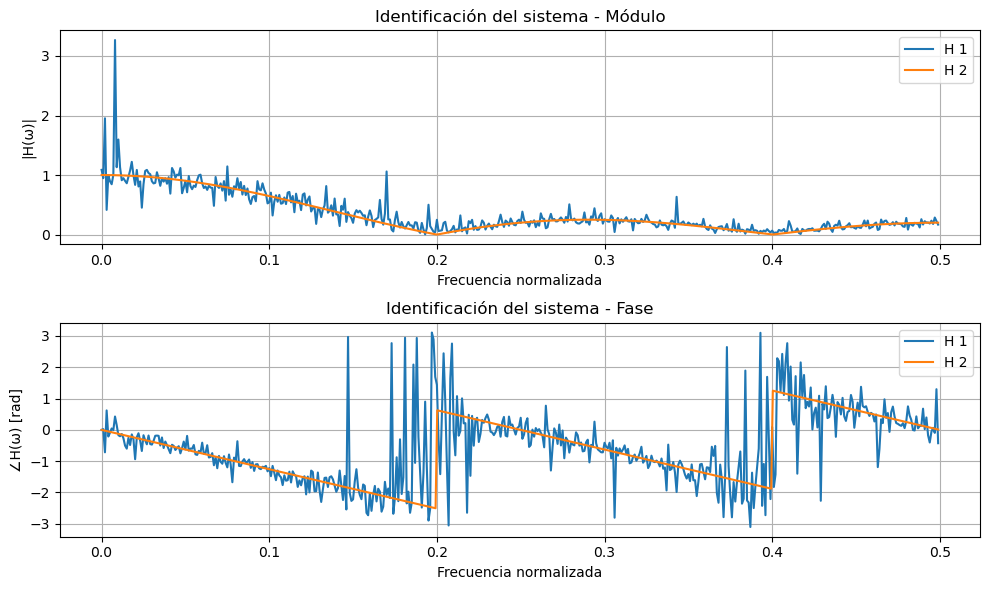

In [51]:
# Sistema a identificar
sistema_a_identificar = filtro_media_movil(5)

entrada = tonos_con_ruido

# Salida del sistema
salida = filtrar_convolucion(
    entrada,
    sistema_a_identificar
)[:len(entrada)]

# H identificada
H_identificada, freqs_id = calcular_H(
    entrada,
    salida
)

# H teórica
impulso = np.zeros(1024)
impulso[0] = 1

salida_teorica = filtrar_convolucion(
    impulso,
    sistema_a_identificar
)[:1024]

H_teorica, freqs_teo = calcular_H(
    impulso,
    salida_teorica
)

# Graficar usando función propia
graficar_H(
    [H_identificada, H_teorica],
    [freqs_id, freqs_teo],
    titulo="Identificación del sistema",
    titles=[
        "H(ω) identificada",
        "H(ω) teórica"
    ]
)

### 7. VARIACION DE PARAMETROS

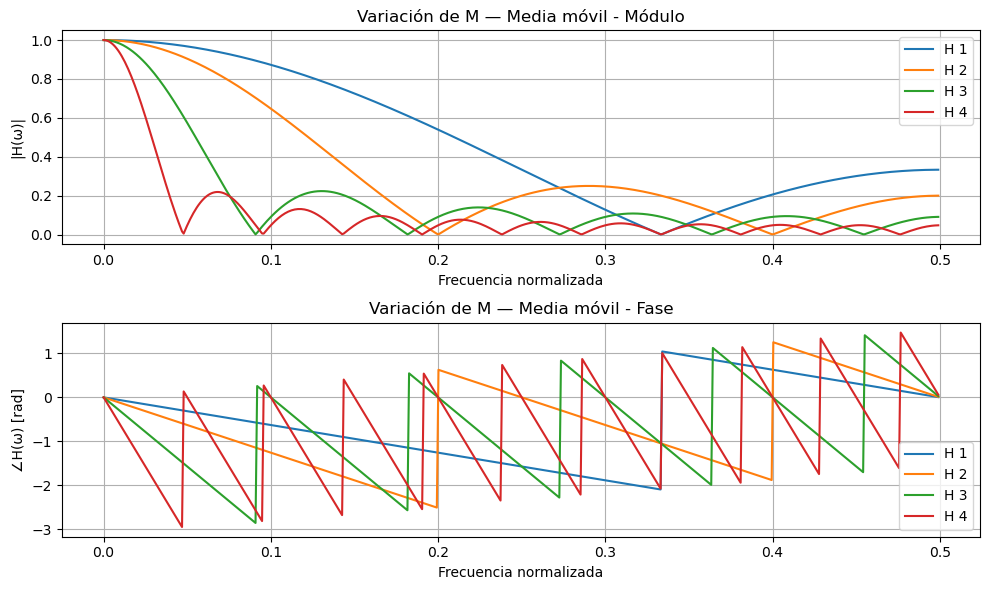

In [52]:
# ==================================================
# Variación del parámetro M — filtro media móvil
# ==================================================

M_values = [3, 5, 11, 21]

N = 1024
impulso = np.zeros(N)
impulso[0] = 1

H_lista = []
freqs_lista = []

for M in M_values:

    h = filtro_media_movil(M)

    y = filtrar_convolucion(
        impulso,
        h
    )[:N]

    H, freqs = calcular_H(
        impulso,
        y
    )

    H_lista.append(H)
    freqs_lista.append(freqs)

graficar_H(
    H_lista,
    freqs_lista,
    titulo="Variación de M — Media móvil"
)

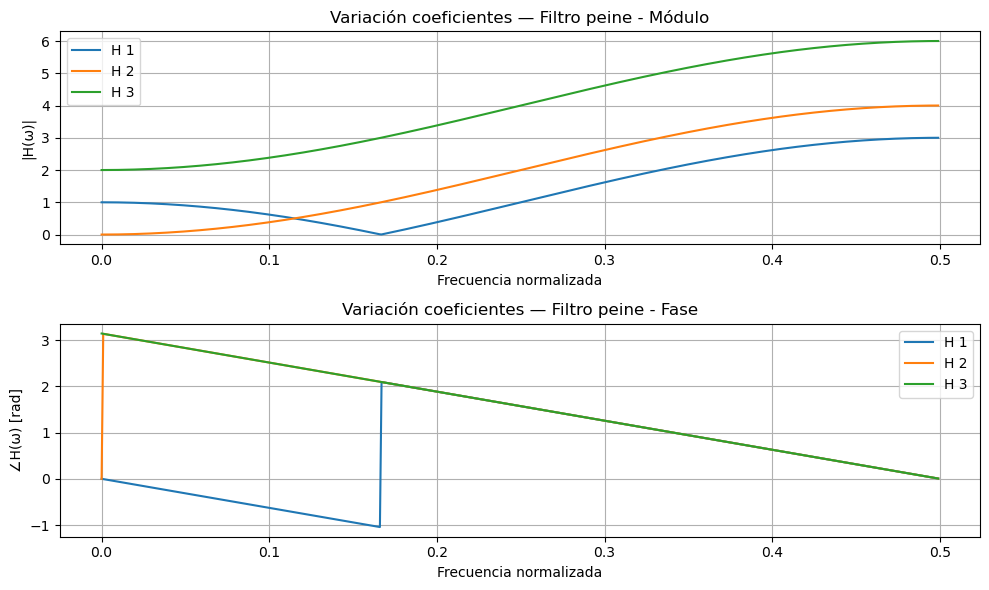

In [19]:
# ==================================================
# Variación coeficientes — filtro peine
# ==================================================

coeficientes = [
    [1, -1, 1],
    [1, -2, 1],
    [1, -4, 1]
]

H_lista = []
freqs_lista = []

for b0, b1, b2 in coeficientes:

    h = filtro_peine(
        b0,
        b1,
        b2
    )

    y = filtrar_convolucion(
        impulso,
        h
    )[:N]

    H, freqs = calcular_H(
        impulso,
        y
    )

    H_lista.append(H)
    freqs_lista.append(freqs)

graficar_H(
    H_lista,
    freqs_lista,
    titulo="Variación coeficientes — Filtro peine"
)

Se observó experimentalmente que al aumentar M en el filtro de media móvil el lóbulo principal se estrecha y aumenta la atenuación fuera de banda, verificando un incremento de selectividad.

En el filtro peine se observó que la modificación de coeficientes altera la profundidad y distribución de máximos y mínimos espectrales.

### 8. TRUNCADO DE LOS COEFICIENTES FIR

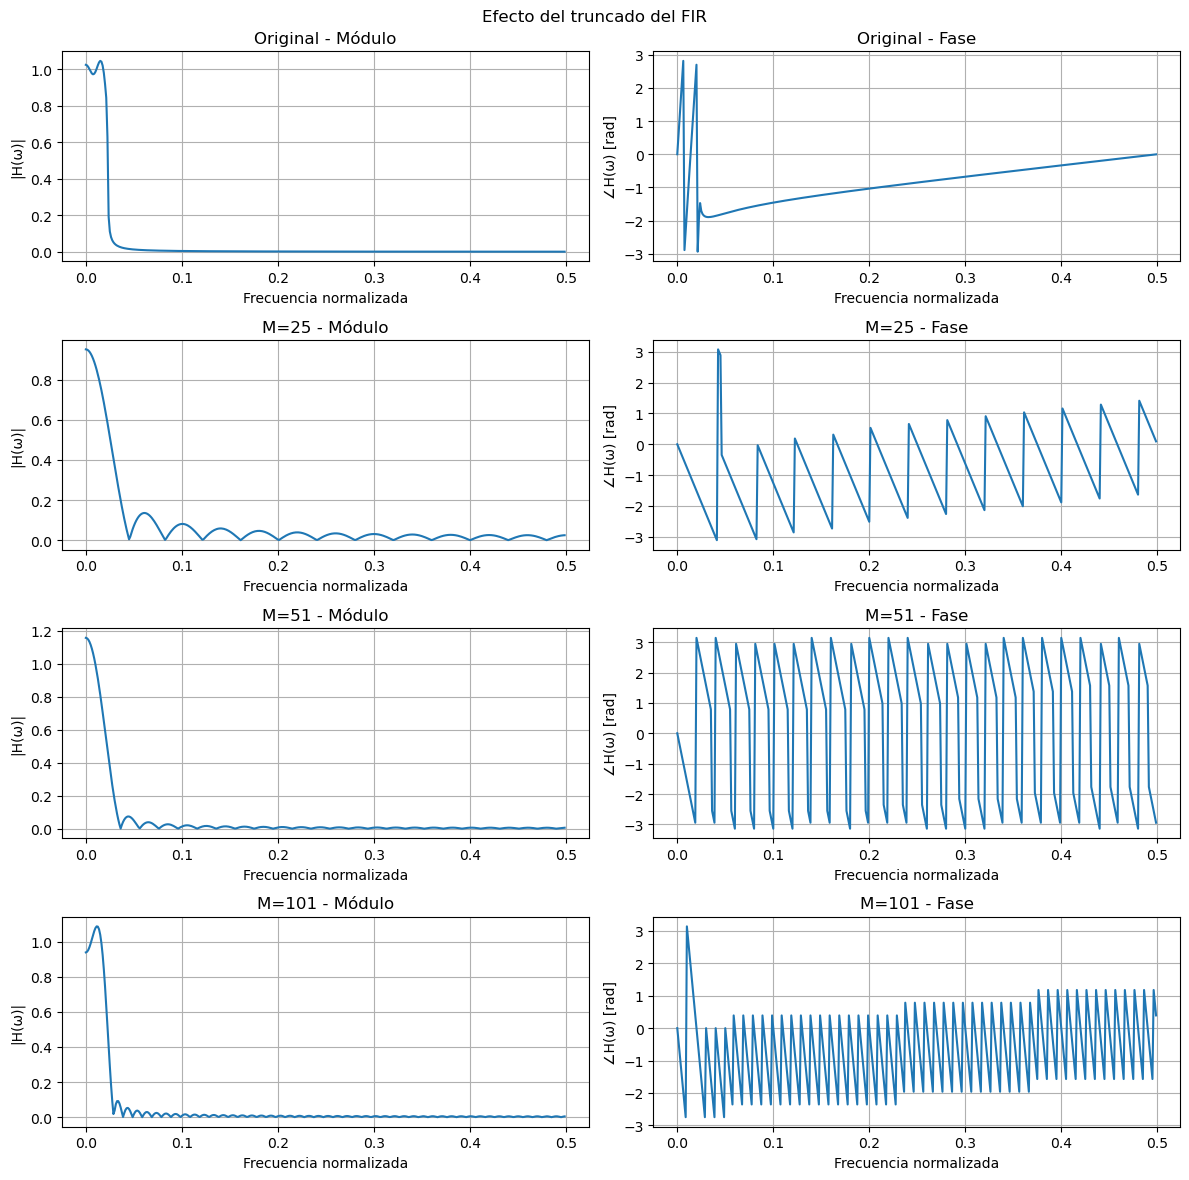

In [66]:
M_values = [25, 51, 101]

filtros = []

for M in M_values:

    h = truncar_fir(
        fir,
        M
    )

    filtros.append(h)

N = 800

impulso = np.zeros(N)
impulso[0] = 1

H_lista = []
freqs_lista = []

# FIR original
y = filtrar_convolucion(
    impulso,
    fir
)[:N]

H, freqs = calcular_H(
    impulso,
    y
)

H_lista.append(H)
freqs_lista.append(freqs)

# Truncados
for h in filtros:

    y = filtrar_convolucion(
        impulso,
        h
    )[:N]

    H, _ = calcular_H(
        impulso,
        y
    )

    H_lista.append(H)
    freqs_lista.append(freqs)

graficar_H(
    H_lista,
    freqs_lista,
    titulo="Efecto del truncado del FIR",
    subplots=True,
    titles=[
        "Original",
        "M=25",
        "M=51",
        "M=101"
    ]
)